In [67]:
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , TensorDataset


In [68]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [69]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "without_mask" in dirs:
        print(os.path.join(root, "without_mask"))

/content/drive/MyDrive/datasets (1)/without_mask


cuda
686
(412, 501)
RGB


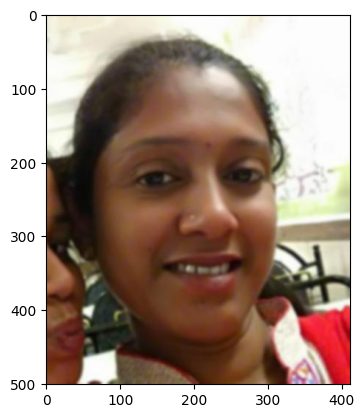

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
import os
from PIL import Image
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/datasets (1)/without_mask"

print(len(os.listdir(path)))

img_name = os.listdir(path)[0]

img = Image.open(os.path.join(path, img_name))

print(img.size)
print(img.mode)

plt.imshow(img)
plt.show()

In [71]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

from torch.utils.data import Dataset
from PIL import Image
import os

class FaceDataset(Dataset):

    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.images = [
            f for f in os.listdir(path)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.path,
            self.images[idx]
        )

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img
    
dataset = FaceDataset(
    path,
    transform=transform
)

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


In [72]:
class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        # ENCODER

        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)

        self.mu = nn.Linear(512, 64)
        self.logvar = nn.Linear(512, 64)

        # DECODER

        self.fc3 = nn.Linear(64, 512)
        self.fc4 = nn.Linear(512, 1024)

        self.fc5 = nn.Linear(1024, 3072)

    def encoder(self, x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        mu = self.mu(x)
        logvar = self.logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def decoder(self, z):

        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))

        x_hat = self.fc5(z)

        return x_hat

    def forward(self, x):

        mu, logvar = self.encoder(x)

        z = self.reparameterize(mu, logvar)

        x_hat = self.decoder(z)

        return x_hat, mu, logvar

In [73]:
model=VAE().to(device)

loss_fn=nn.MSELoss(reduction='sum')
lr=0.001
optimizer=torch.optim.Adam(model.parameters() , lr=lr)


In [85]:
epochs = 20


for epoch in range(epochs):

    total_loss = 0

    for x in loader:

        # Flatten
        x=x.to(device)
        x = x.view(x.size(0), -1)

        # Forward
        x_hat, mu, logvar = model(x)

        # Reconstruction loss
        recon_loss = loss_fn(x_hat, x)

        # KL loss
        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp()
        )
        
        beta =0.01
        # Total
        loss = recon_loss + beta * kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1}")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Recon Loss: {recon_loss.item():.2f}")
    print(f"KL Loss: {kl_loss.item():.2f}")


Epoch 1
Total Loss: 85595.38
Recon Loss: 5679.52
KL Loss: 3774.90

Epoch 2
Total Loss: 82874.02
Recon Loss: 5323.85
KL Loss: 5047.50

Epoch 3
Total Loss: 81078.69
Recon Loss: 4882.71
KL Loss: 5538.49

Epoch 4
Total Loss: 79365.34
Recon Loss: 5211.13
KL Loss: 6114.77

Epoch 5
Total Loss: 76612.91
Recon Loss: 4903.66
KL Loss: 6712.90

Epoch 6
Total Loss: 74147.90
Recon Loss: 5099.21
KL Loss: 6821.71

Epoch 7
Total Loss: 72174.24
Recon Loss: 4935.03
KL Loss: 6591.83

Epoch 8
Total Loss: 70561.54
Recon Loss: 4609.35
KL Loss: 6802.62

Epoch 9
Total Loss: 69261.81
Recon Loss: 4925.26
KL Loss: 6889.46

Epoch 10
Total Loss: 67480.68
Recon Loss: 4164.85
KL Loss: 7046.30

Epoch 11
Total Loss: 66795.96
Recon Loss: 4450.87
KL Loss: 6968.97

Epoch 12
Total Loss: 66141.94
Recon Loss: 4545.86
KL Loss: 7033.92

Epoch 13
Total Loss: 65042.70
Recon Loss: 4004.52
KL Loss: 7020.48

Epoch 14
Total Loss: 64179.01
Recon Loss: 4335.83
KL Loss: 7287.09

Epoch 15
Total Loss: 63772.43
Recon Loss: 3985.85
KL Los

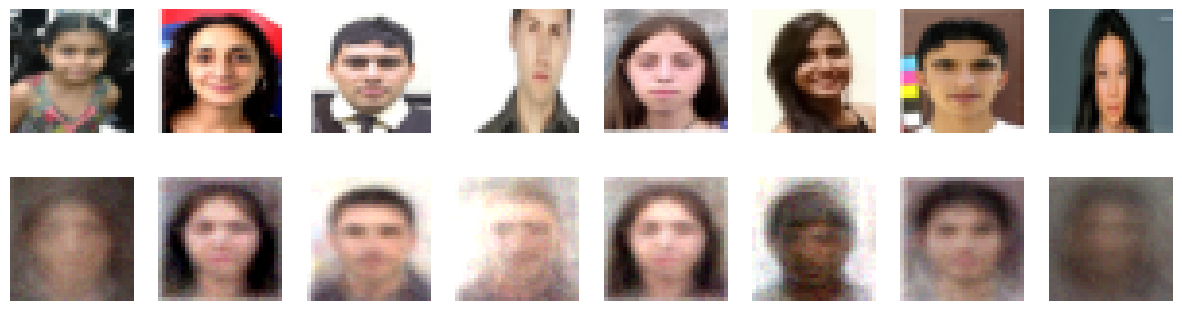

In [ ]:
model.eval()

with torch.no_grad():

    x = next(iter(loader))

    x = x.to(device)

    # flatten
    x_flat = x.view(x.size(0), -1)

    x_hat, _, _ = model(x_flat)

    # reshape back for visualization
    x_hat = x_hat.view(-1, 3, 32, 32)

    x = x.cpu()
    x_hat = x_hat.cpu()
    
fig, axes = plt.subplots(2, 8, figsize=(15,4))

for i in range(8):

    # original
    axes[0,i].imshow(x[i].permute(1,2,0))
    axes[0,i].axis('off')

    # reconstruction
    axes[1,i].imshow(x_hat[i].permute(1,2,0))
    axes[1,i].axis('off')

plt.show()

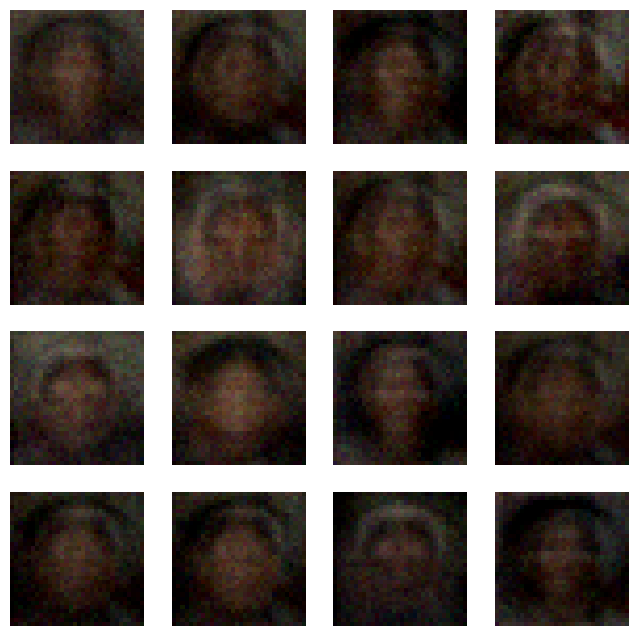

In [102]:
model.eval()

with torch.no_grad():

    z = torch.randn(16, 64).to(device)

    generated = model.decoder(z)

    generated = generated.cpu()

    generated = generated.view(-1, 3, 32, 32)

fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flat):

    img = generated[i].permute(1,2,0)

    ax.imshow(img.clamp(0,1))

    ax.axis("off")

plt.show()

IndexError: index 4 is out of bounds for dimension 0 with size 4

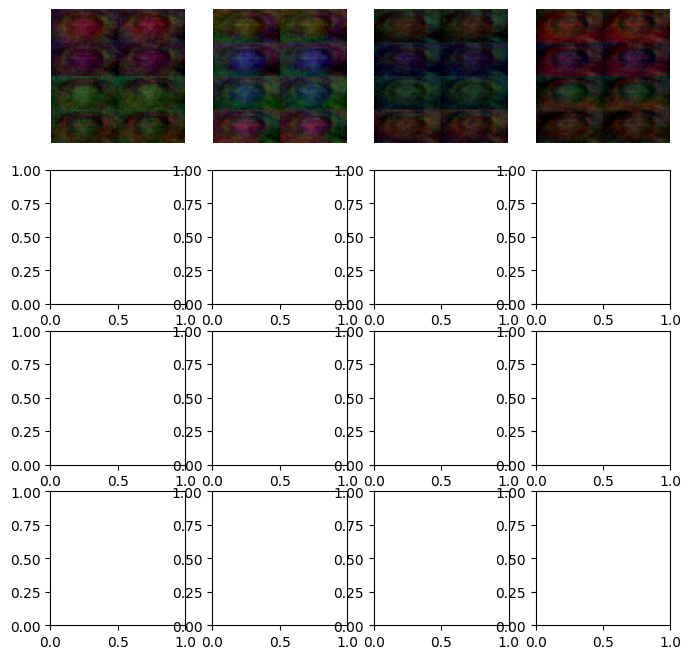

In [99]:
fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flat):

    img = generated[i].permute(1,2,0)

    ax.imshow(img.clamp(0,1))

    ax.axis("off")

plt.show()